<h1>Application of Closed-loop learning to k-means clustering of Iris dataset</h1>

<h2>Gabriele Cerioli, Bsc Physics, University of Trieste</h2>

<h3>Defining Euclidean distance and the main function kmeans</h3>

In [1]:
def euclidean_distance(a,b):
    return np.sqrt(np.sum((a-b)**2))

def kmeans(data_matrix, n_clusters, steps):
    import numpy as np
    # data_matrix may be a matrix with 4 columns ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
    max_values=np.max(data_matrix, axis=0)
    min_values=np.min(data_matrix, axis=0)
    initial_centroids=np.random.uniform(min_values, max_values, (n_clusters,data_matrix.shape[1]))
    
    cluster_assignments = np.zeros(data_matrix.shape[0])
    for i in range(data_matrix.shape[0]):
        distances = np.array([euclidean_distance(data_matrix[i], centroid) for centroid in initial_centroids])
        cluster_assignments[i] = np.argmin(distances)
    
    for i in range(steps):
        for j in range(n_clusters):
            points_in_cluster = data_matrix[cluster_assignments == j]
            if len(points_in_cluster) > 0:
                initial_centroids[j] = np.mean(points_in_cluster, axis=0)
        for k in range(data_matrix.shape[0]):
            distances = np.array([euclidean_distance(data_matrix[k], centroid) for centroid in initial_centroids])
            cluster_assignments[k] = np.argmin(distances)
    return cluster_assignments



<h3>Defining functions means and variances for the clusters</h3>

In [2]:
def mean_clusters(data_matrix,cluster_assignments, n_clusters):
    mean_cluster = np.zeros((n_clusters, data_matrix.shape[1]))
    for j in range(n_clusters):
        points_in_cluster = data_matrix[cluster_assignments == j]
        if len(points_in_cluster) > 0:
            mean_cluster[j] = np.mean(points_in_cluster, axis=0)
    return mean_cluster
def variance_clusters(data_matrix,cluster_assignments, n_clusters):
    variance_cluster = np.zeros((n_clusters, data_matrix.shape[1]))
    for j in range(n_clusters):
        points_in_cluster = data_matrix[cluster_assignments == j]
        if len(points_in_cluster) > 0:
            variance_cluster[j] = np.var(points_in_cluster, axis=0)
    return variance_cluster


<h3>Defining function to plot the 6 2-d graphs</h3>

In [3]:
def plot_clusters(data_matrix, cluster_assignments, centroids):
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 3, figsize=(10, 8))  # 2 righe, 3 colonne
    
    # Scatter 1: SepalLength vs SepalWidth
    axes[0, 0].scatter(data_matrix[:,0], data_matrix[:,1], c=cluster_assignments, cmap='winter', alpha=0.6)
    axes[0, 0].scatter(centroids[:,0], centroids[:,1], c='red', marker='X', s=100, label='Centroidi')
    axes[0, 0].set_xlabel("Sepal Length (cm)")
    axes[0, 0].set_ylabel("Sepal Width (cm)")
    axes[0, 0].legend()

    # Scatter 2: SepalLength vs PetalLength
    axes[0, 1].scatter(data_matrix[:,0], data_matrix[:,2], c=cluster_assignments, cmap='winter', alpha=0.6)
    axes[0, 1].scatter(centroids[:,0], centroids[:,2], c='red', marker='X', s=100)
    axes[0, 1].set_xlabel("Sepal Length (cm)")
    axes[0, 1].set_ylabel("Petal Length (cm)")

    # Scatter 3: SepalLength vs PetalWidth
    axes[0, 2].scatter(data_matrix[:,0], data_matrix[:,3], c=cluster_assignments, cmap='winter', alpha=0.6)
    axes[0, 2].scatter(centroids[:,0], centroids[:,3], c='red', marker='X', s=100)
    axes[0, 2].set_xlabel("Sepal Length (cm)")
    axes[0, 2].set_ylabel("Petal Width (cm)")

    # Scatter 4: SepalWidth vs PetalLength
    axes[1, 0].scatter(data_matrix[:,1], data_matrix[:,2], c=cluster_assignments, cmap='winter', alpha=0.6)
    axes[1, 0].scatter(centroids[:,1], centroids[:,2], c='red', marker='X', s=100)
    axes[1, 0].set_xlabel("Sepal Width (cm)")
    axes[1, 0].set_ylabel("Petal Length (cm)")

    # Scatter 5: SepalWidth vs PetalWidth
    axes[1, 1].scatter(data_matrix[:,1], data_matrix[:,3], c=cluster_assignments, cmap='winter', alpha=0.6)
    axes[1, 1].scatter(centroids[:,1], centroids[:,3], c='red', marker='X', s=100)
    axes[1, 1].set_xlabel("Sepal Width (cm)")
    axes[1, 1].set_ylabel("Petal Width (cm)")

    # Scatter 6: PetalLength vs PetalWidth
    axes[1, 2].scatter(data_matrix[:,2], data_matrix[:,3], c=cluster_assignments, cmap='winter', alpha=0.6)
    axes[1, 2].scatter(centroids[:,2], centroids[:,3], c='red', marker='X', s=100)
    axes[1, 2].set_xlabel("Petal Length (cm)")
    axes[1, 2].set_ylabel("Petal Width (cm)")

    fig.suptitle("Visualisation of Clusters and their centroids", fontsize=16, fontweight='bold')
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    return()

<h3>Defining function to update dataset with synthetic data</h3>

In [4]:
def update_dataset(data_matrix,cluster_assignments,M,means,variances):
    # Tot-M sampled real points
    sampled_points=data_matrix[np.random.choice(data_matrix.shape[0], size=data_matrix.shape[0]-M, replace=False)]

    # M synthetic_points from gaussian mixtures
    weights=np.zeros(means.shape[0])
    for i in range(means.shape[0]):
        weights[i]=np.sum(cluster_assignments==i)/len(cluster_assignments)
    synthetic_points=np.zeros((M,data_matrix.shape[1]))
    clusters=np.arange(means.shape[0])
    for j in range(M):
        cluster_index=np.random.choice(clusters,p=weights)#Scelta del cluster da cui generare
        synthetic_points[j]=np.random.normal(loc=means[cluster_index],scale=variances[cluster_index])
    new_data=np.vstack((sampled_points,synthetic_points))
    return(new_data)

<h3>Main algorithm</h3>

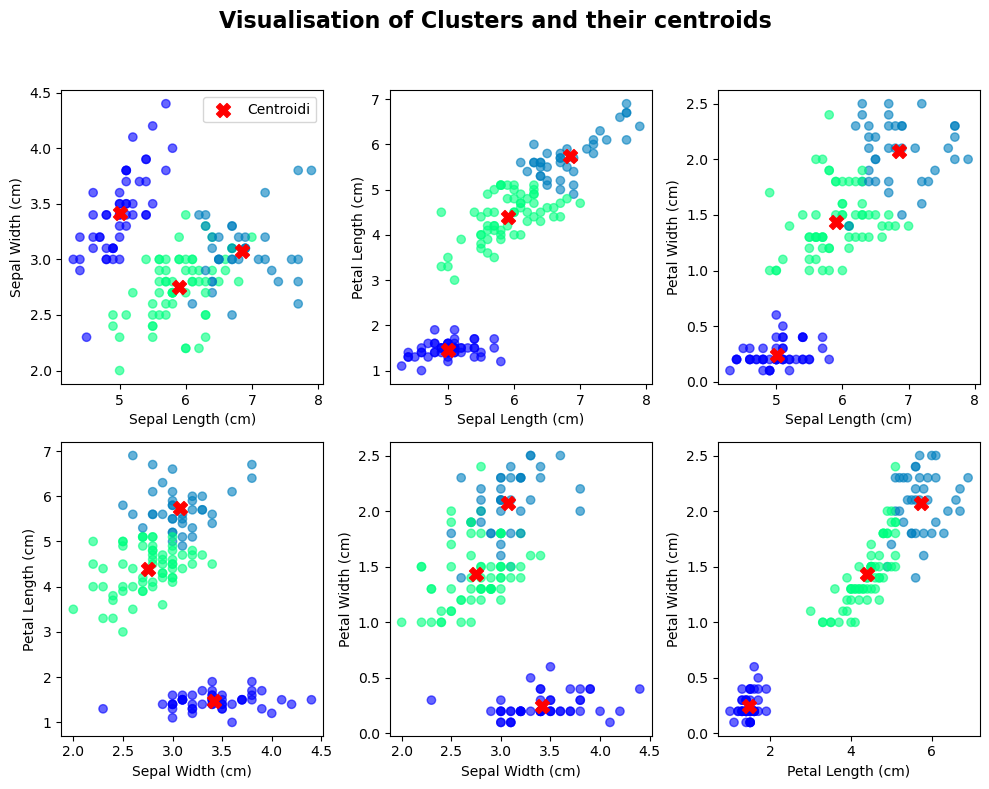

50 38 62


In [5]:
import pandas as pd
import numpy as np
M=100 #points to be substituted with synthetic data
df=pd.read_csv('Iris.csv')

selected_columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
data_matrix = df[selected_columns].to_numpy()

cluster_assignments=kmeans(data_matrix, 3, 100)
plot_clusters(data_matrix,cluster_assignments,mean_clusters(data_matrix,cluster_assignments, 3))
print(np.sum(cluster_assignments==0),np.sum(cluster_assignments==1),np.sum(cluster_assignments==2))
new_data=data_matrix
steps=50 # Number of iterations
i=0
while i<=steps:
    means=mean_clusters(new_data,cluster_assignments, 3)
    variances=variance_clusters(new_data,cluster_assignments, 3)
    new_data=update_dataset(data_matrix, cluster_assignments,M,means,variances)
    cluster_assignments=kmeans(new_data, 3, 100)
    i+=1

<h3>After the closed-loop learning cycle:</h3>

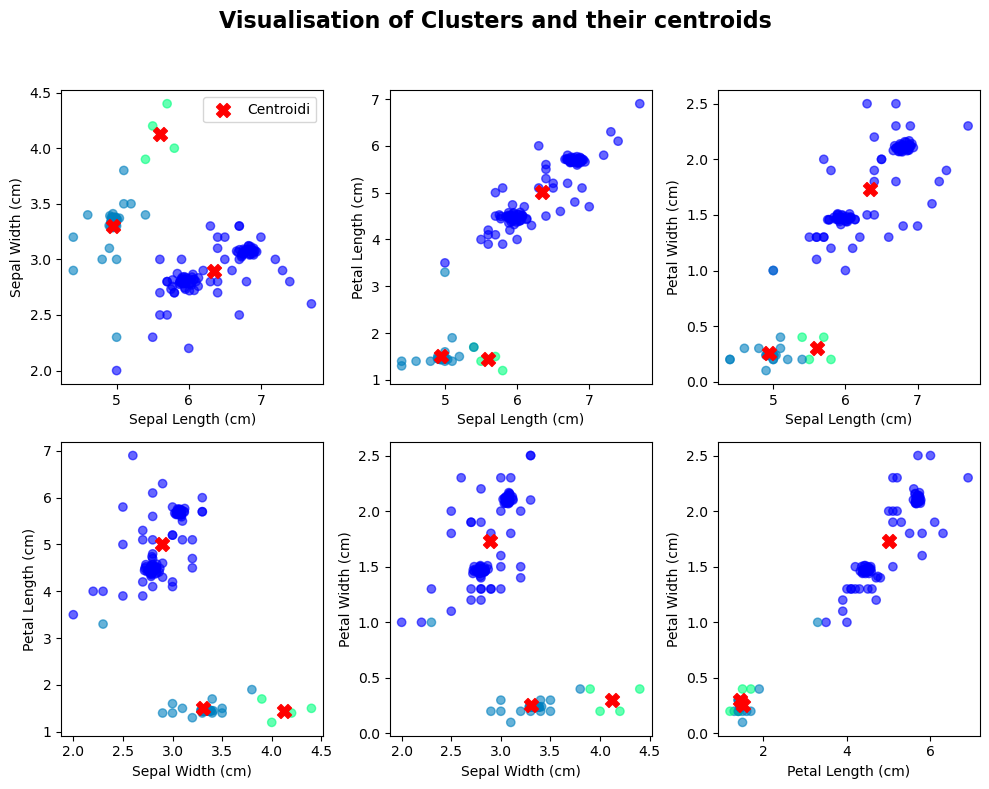

100 46 4


In [6]:
plot_clusters(new_data,cluster_assignments,mean_clusters(new_data,cluster_assignments, 3))
print(np.sum(cluster_assignments==0),np.sum(cluster_assignments==1),np.sum(cluster_assignments==2))

<h3>Purity score:</h3>

In [9]:
def infomax(labels):
    M = len(labels)
    unique, counts = np.unique(labels, return_counts=True)
    probs = counts / M
    H = -np.sum(probs * np.log(probs))
    return H
from sklearn.metrics import davies_bouldin_score

import numpy as np
from sklearn.metrics import confusion_matrix

def purity_score(y_true, y_pred):
    """
    Calcola la purity tra etichette vere (y_true) e assegnazioni di clustering (y_pred).
    
    Parameters:
    - y_true: array-like, etichette reali
    - y_pred: array-like, etichette di clustering
    
    Returns:
    - purity: float, valore tra 0 e 1
    """
    # Matrice di contingenza: righe = classi vere, colonne = cluster
    contingency_matrix = confusion_matrix(y_true, y_pred)
    
    # Somma dei massimi per ogni colonna (cluster)
    max_per_cluster = np.max(contingency_matrix, axis=0)
    
    # Purezza = somma dei massimi / totale dei campioni
    purity = np.sum(max_per_cluster) / np.sum(contingency_matrix)
    
    return purity
centroids=mean_clusters(new_data,cluster_assignments, 3)
print(centroids)

# Rieseguiamo un k-means sui centroidi trovati con il CLL-clustering
import numpy as np
df=pd.read_csv('Iris.csv')
selected_columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
data_matrix = df[selected_columns].to_numpy()
steps=30
n_clusters=3
max_values=np.max(data_matrix, axis=0)
min_values=np.min(data_matrix, axis=0)
initial_centroids=centroids

cluster_assignments = np.zeros(data_matrix.shape[0])
for i in range(data_matrix.shape[0]):
    distances = np.array([euclidean_distance(data_matrix[i], centroid) for centroid in initial_centroids])
    cluster_assignments[i] = np.argmin(distances)

for i in range(steps):
    for j in range(n_clusters):
        points_in_cluster = data_matrix[cluster_assignments == j]
        if len(points_in_cluster) > 0:
            initial_centroids[j] = np.mean(points_in_cluster, axis=0)
    for k in range(data_matrix.shape[0]):
        distances = np.array([euclidean_distance(data_matrix[k], centroid) for centroid in initial_centroids])
        cluster_assignments[k] = np.argmin(distances)




print("Clustering")
print(cluster_assignments)

ground_truth = np.array([0]*50 + [1]*50 + [2]*50)
print("Purity score of CLL:",purity_score(ground_truth,cluster_assignments))
print(confusion_matrix(ground_truth,cluster_assignments))
print("Davies-Bouldin score of CLL:", davies_bouldin_score(data_matrix, cluster_assignments))
print("Infomax score of CLL:", infomax(cluster_assignments))

[[5.85278884 3.06689152 3.76509474 1.22114354]
 [6.05741651 2.97875151 4.16359378 1.35887896]
 [5.88333333 3.0875     3.77083333 1.19166667]]
Clustering
[2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 0.
 1. 0. 1. 0. 1. 1. 0. 0. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 0. 1.
 1. 1. 0. 1. 1. 0.]
Purity score of CLL: 0.8866666666666667
[[ 0  0 50]
 [47  3  0]
 [14 36  0]]
Davies-Bouldin score of CLL: 0.6663912107101473
Infomax score of CLL: 1.082346226196019
